In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

# 1. Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target) # 0 = Malignant, 1 = Benign

# 2. Split Data
# Random State is CRITICAL here. All models must see the exact same training data to be fair.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale Data (Required for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Loaded & Scaled.")

Data Loaded & Scaled.


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 4. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# 5. Training Loop
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

print("Training Complete. Models Evaluated.")

Training Complete. Models Evaluated.


--- Model Performance Comparison ---
                 Model  Accuracy  Precision    Recall  F1 Score
3                  SVM  0.982456   0.972603  1.000000  0.986111
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
2        Random Forest  0.964912   0.958904  0.985915  0.972222
1        Decision Tree  0.947368   0.957746  0.957746  0.957746
4                  KNN  0.947368   0.957746  0.957746  0.957746


/tmp/ipython-input-505/2049517047.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


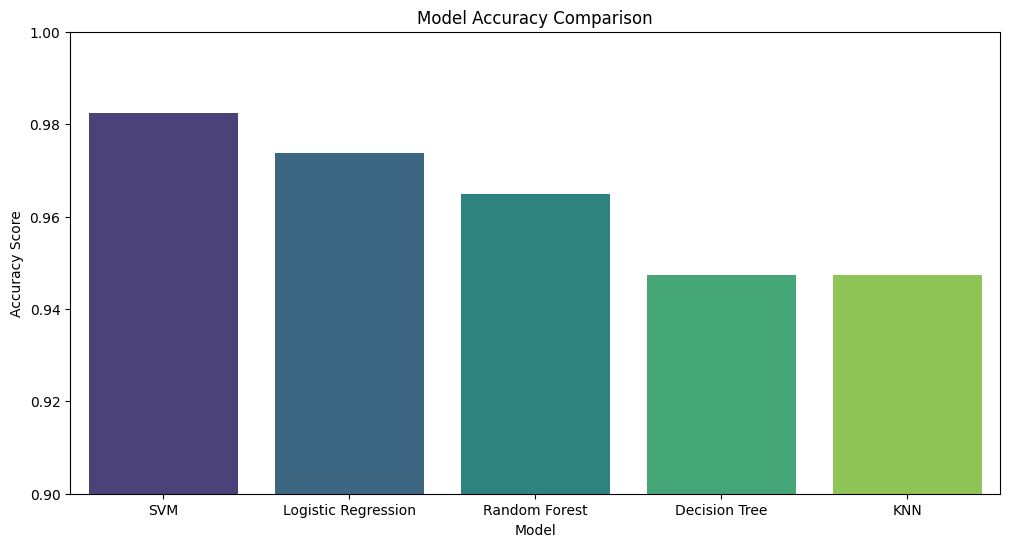

/tmp/ipython-input-505/2049517047.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 Score', data=results_df, palette='magma')


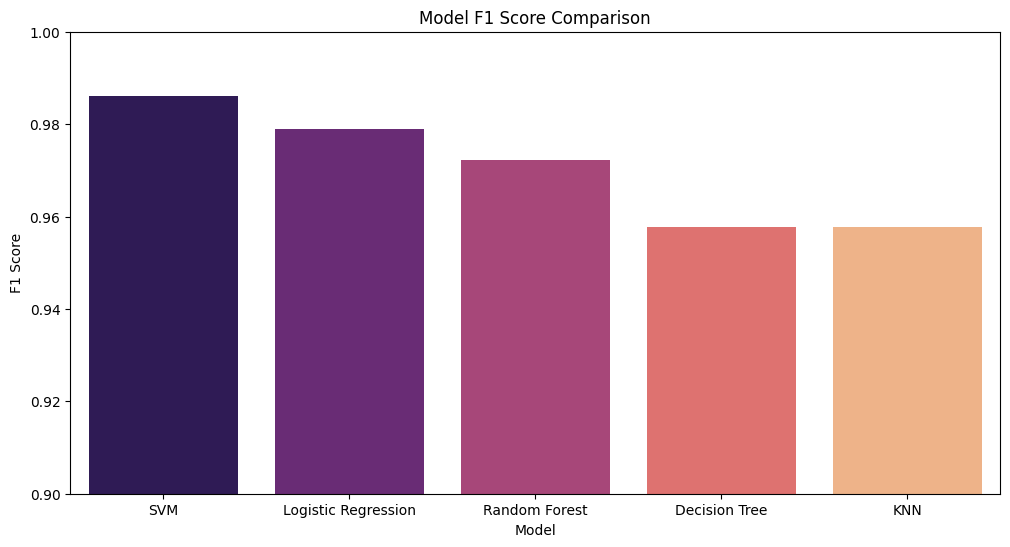

In [3]:
# 6. Create Comparison Table
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)

print("--- Model Performance Comparison ---")
print(results_df)

# 7. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.ylim(0.9, 1.0) # Zoom in to see differences
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()

# Visualize F1 Score as well (better for imbalanced data)
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1 Score', data=results_df, palette='magma')
plt.ylim(0.9, 1.0)
plt.title("Model F1 Score Comparison")
plt.show()

In [4]:
# 8. Select Best Model
# We pick based on F1 Score (balances Precision and Recall)
best_model_name = results_df.iloc[0]['Model']
best_score = results_df.iloc[0]['F1 Score']

print(f"🏆 The Best Model is: {best_model_name} with F1 Score: {best_score:.4f}")

# Retrieve the actual model object
best_model = models[best_model_name]

# 9. Save Best Model
joblib.dump(best_model, 'best_model.pkl')
print(f"Saved {best_model_name} to 'best_model.pkl'")

🏆 The Best Model is: SVM with F1 Score: 0.9861
Saved SVM to 'best_model.pkl'
